In [6]:
from pathlib import Path
from PIL import Image

dataset_path = Path("/scratch/ms4764/LIDC-IDRI-slices/LIDC-IDRI-slices")

for patient in dataset_path.iterdir():
    for nodule in patient.iterdir():

        image_folder = nodule / "images"
        mask_folder = nodule / "mask-0"

        if image_folder.exists() and mask_folder.exists():
            img_path = list(image_folder.glob("*.png"))[0]
            mask_path = list(mask_folder.glob("*.png"))[0]

            img = Image.open(img_path)
            mask = Image.open(mask_path)

            print("Image size:", img.size)
            print("Mask size :", mask.size)
            print("Image mode:", img.mode)
            print("Mask mode :", mask.mode)

            break
    break

Image size: (128, 128)
Mask size : (128, 128)
Image mode: L
Mask mode : L


In [8]:
import os
from glob import glob
from pathlib import Path

import numpy as np
from PIL import Image
from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader


dataset_path = Path("/scratch/ms4764/LIDC-IDRI-slices/LIDC-IDRI-slices")

IMG_HEIGHT = 128
IMG_WIDTH = 128
IMG_CHANNELS = 1
MASK_CHANNELS = 1

BATCH_SIZE = 8
EPOCHS = 30
LEARNING_RATE = 1e-4

torch.manual_seed(42)
np.random.seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [10]:

# COLLECT IMAGE AND MASK PATHS BY PATIENT

patient_samples = {}

for patient in sorted(os.listdir(dataset_path)):
    patient_path = os.path.join(dataset_path, patient)

    if patient.startswith(".") or not os.path.isdir(patient_path):
        continue

    patient_samples[patient] = []

    for nodule in sorted(os.listdir(patient_path)):
        nodule_path = os.path.join(patient_path, nodule)

        if nodule.startswith(".") or not os.path.isdir(nodule_path):
            continue

        image_files = sorted(glob(os.path.join(nodule_path, "images", "*.png")))
        mask_files = sorted(glob(os.path.join(nodule_path, "mask-0", "*.png")))

        number_of_files = min(len(image_files), len(mask_files))

        for file_index in range(number_of_files):
            patient_samples[patient].append(
                (image_files[file_index], mask_files[file_index])
            )

# remove patients with no valid slices
patient_samples = {
    patient: samples
    for patient, samples in patient_samples.items()
    if len(samples) > 0
}

patient_ids = sorted(list(patient_samples.keys()))

print("Total patients:", len(patient_ids))
print("Total image-mask pairs:", sum(len(patient_samples[p]) for p in patient_ids))


Total patients: 875
Total image-mask pairs: 15548


In [11]:

# PATIENT-LEVEL 80 / 10 / 10 SPLIT

train_patients, temp_patients = train_test_split(
    patient_ids,
    test_size=0.2,
    random_state=42,
    shuffle=True
)

val_patients, test_patients = train_test_split(
    temp_patients,
    test_size=0.5,
    random_state=42,
    shuffle=True
)

print("Train patients:", len(train_patients))
print("Val patients  :", len(val_patients))
print("Test patients :", len(test_patients))


def load_samples_from_patients(selected_patients, patient_samples):
    images = []
    masks = []

    for patient in selected_patients:
        for image_path, mask_path in patient_samples[patient]:
            try:
                image_data = Image.open(image_path).convert("L")
                image_data = np.array(image_data, dtype=np.float32) / 255.0

                mask_data = Image.open(mask_path).convert("L")
                mask_data = np.array(mask_data, dtype=np.float32) / 255.0

            except Exception as error:
                print("Skipping file because of error:", error)
                continue

            mask_data = (mask_data > 0.5).astype(np.float32)

            image_data = np.expand_dims(image_data, axis=0)
            mask_data = np.expand_dims(mask_data, axis=0)

            images.append(image_data)
            masks.append(mask_data)

    images = np.array(images, dtype=np.float32)
    masks = np.array(masks, dtype=np.float32)

    images = np.nan_to_num(images)
    masks = np.nan_to_num(masks)

    return images, masks


x_train, mask_train = load_samples_from_patients(train_patients, patient_samples)
x_val, mask_val = load_samples_from_patients(val_patients, patient_samples)
x_test, mask_test = load_samples_from_patients(test_patients, patient_samples)

print("x_train:", x_train.shape)
print("mask_train:", mask_train.shape)

print("x_val:", x_val.shape)
print("mask_val:", mask_val.shape)

print("x_test:", x_test.shape)
print("mask_test:", mask_test.shape)

Train patients: 700
Val patients  : 87
Test patients : 88
x_train: (12581, 1, 128, 128)
mask_train: (12581, 1, 128, 128)
x_val: (1473, 1, 128, 128)
mask_val: (1473, 1, 128, 128)
x_test: (1494, 1, 128, 128)
mask_test: (1494, 1, 128, 128)


In [12]:

train_loader = DataLoader(
    TensorDataset(
        torch.tensor(x_train, dtype=torch.float32),
        torch.tensor(mask_train, dtype=torch.float32)
    ),
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    TensorDataset(
        torch.tensor(x_val, dtype=torch.float32),
        torch.tensor(mask_val, dtype=torch.float32)
    ),
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loader = DataLoader(
    TensorDataset(
        torch.tensor(x_test, dtype=torch.float32),
        torch.tensor(mask_test, dtype=torch.float32)
    ),
    batch_size=BATCH_SIZE,
    shuffle=False
)


In [13]:

# U-NET MODEL

class DoubleConv(nn.Module):
    def __init__(self, input_channels, output_channels):
        super().__init__()

        self.block = nn.Sequential(
            nn.Conv2d(input_channels, output_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(output_channels),
            nn.ReLU(inplace=True),

            nn.Conv2d(output_channels, output_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(output_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.block(x)


class UNet(nn.Module):
    def __init__(self, input_channels=1, output_channels=1):
        super().__init__()

        self.down1 = DoubleConv(input_channels, 64)
        self.pool1 = nn.MaxPool2d(2)

        self.down2 = DoubleConv(64, 128)
        self.pool2 = nn.MaxPool2d(2)

        self.down3 = DoubleConv(128, 256)
        self.pool3 = nn.MaxPool2d(2)

        self.bridge = DoubleConv(256, 512)

        self.up3 = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2)
        self.conv3 = DoubleConv(512, 256)

        self.up2 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.conv2 = DoubleConv(256, 128)

        self.up1 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.conv1 = DoubleConv(128, 64)

        self.final = nn.Conv2d(64, output_channels, kernel_size=1)

    def forward(self, x):
        skip1 = self.down1(x)
        x = self.pool1(skip1)

        skip2 = self.down2(x)
        x = self.pool2(skip2)

        skip3 = self.down3(x)
        x = self.pool3(skip3)

        x = self.bridge(x)

        x = self.up3(x)
        x = torch.cat([x, skip3], dim=1)
        x = self.conv3(x)

        x = self.up2(x)
        x = torch.cat([x, skip2], dim=1)
        x = self.conv2(x)

        x = self.up1(x)
        x = torch.cat([x, skip1], dim=1)
        x = self.conv1(x)

        return self.final(x)



In [15]:
import torch
import torch.nn as nn

class DiceBCELoss(nn.Module):
    def __init__(self):
        super().__init__()
        self.bce = nn.BCEWithLogitsLoss()

    def forward(self, logits, targets, smooth=1e-6):
        bce_loss = self.bce(logits, targets)

        probs = torch.sigmoid(logits)
        probs = probs.contiguous()
        targets = targets.contiguous()

        intersection = (probs * targets).sum(dim=(1, 2, 3))
        union = probs.sum(dim=(1, 2, 3)) + targets.sum(dim=(1, 2, 3))
        dice = (2.0 * intersection + smooth) / (union + smooth)
        dice_loss = 1.0 - dice.mean()

        return bce_loss + dice_loss


def compute_batch_metrics(logits, targets, threshold=0.5, smooth=1e-6):
    probs = torch.sigmoid(logits)
    preds = (probs > threshold).float()

    preds = preds.contiguous()
    targets = targets.contiguous()

    tp = (preds * targets).sum(dim=(1, 2, 3))
    fp = (preds * (1 - targets)).sum(dim=(1, 2, 3))
    fn = ((1 - preds) * targets).sum(dim=(1, 2, 3))

    dice = (2 * tp + smooth) / (2 * tp + fp + fn + smooth)
    iou = (tp + smooth) / (tp + fp + fn + smooth)
    precision = (tp + smooth) / (tp + fp + smooth)
    recall = (tp + smooth) / (tp + fn + smooth)

    return (
        dice.mean().item(),
        iou.mean().item(),
        precision.mean().item(),
        recall.mean().item()
    )

In [16]:
import torch

def train_one_epoch(model, dataloader, optimizer, loss_function, device):
    model.train()
    total_loss = 0.0

    for images, masks in dataloader:
        images = images.to(device)
        masks = masks.to(device)

        optimizer.zero_grad()
        logits = model(images)
        loss = loss_function(logits, masks)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(dataloader)


def evaluate_model(model, dataloader, loss_function, device, threshold=0.5):
    model.eval()

    total_loss = 0.0
    total_dice = 0.0
    total_iou = 0.0
    total_precision = 0.0
    total_recall = 0.0

    with torch.no_grad():
        for images, masks in dataloader:
            images = images.to(device)
            masks = masks.to(device)

            logits = model(images)
            loss = loss_function(logits, masks)

            dice, iou, precision, recall = compute_batch_metrics(
                logits, masks, threshold=threshold
            )

            total_loss += loss.item()
            total_dice += dice
            total_iou += iou
            total_precision += precision
            total_recall += recall

    num_batches = len(dataloader)

    return {
        "loss": total_loss / num_batches,
        "dice": total_dice / num_batches,
        "iou": total_iou / num_batches,
        "precision": total_precision / num_batches,
        "recall": total_recall / num_batches
    }

In [17]:
import torch
import copy

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

unet_model = UNet().to(device)
loss_function = DiceBCELoss()
optimizer = torch.optim.Adam(unet_model.parameters(), lr=1e-4)

num_epochs = 30

best_val_dice = 0.0
best_model_weights = copy.deepcopy(unet_model.state_dict())

for epoch in range(num_epochs):
    train_loss = train_one_epoch(unet_model, train_loader, optimizer, loss_function, device)
    val_results = evaluate_model(unet_model, val_loader, loss_function, device, threshold=0.5)

    print(
        f"Epoch {epoch + 1}/{num_epochs} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_results['loss']:.4f} | "
        f"Val Dice: {val_results['dice']:.4f} | "
        f"Val IoU: {val_results['iou']:.4f} | "
        f"Val Precision: {val_results['precision']:.4f} | "
        f"Val Recall: {val_results['recall']:.4f}"
    )

    if val_results["dice"] > best_val_dice:
        best_val_dice = val_results["dice"]
        best_model_weights = copy.deepcopy(unet_model.state_dict())
        torch.save(best_model_weights, "best_unet_lidc.pth")
        print(f"Saved new best model with Val Dice: {best_val_dice:.4f}")

Using device: cuda
Epoch 1/30 | Train Loss: 1.0573 | Val Loss: 0.7847 | Val Dice: 0.5636 | Val IoU: 0.4687 | Val Precision: 0.6808 | Val Recall: 0.6986
Saved new best model with Val Dice: 0.5636
Epoch 2/30 | Train Loss: 0.5447 | Val Loss: 0.3974 | Val Dice: 0.6526 | Val IoU: 0.5502 | Val Precision: 0.6392 | Val Recall: 0.8393
Saved new best model with Val Dice: 0.6526
Epoch 3/30 | Train Loss: 0.3831 | Val Loss: 0.3715 | Val Dice: 0.6573 | Val IoU: 0.5580 | Val Precision: 0.6827 | Val Recall: 0.8047
Saved new best model with Val Dice: 0.6573
Epoch 4/30 | Train Loss: 0.3560 | Val Loss: 0.3569 | Val Dice: 0.6659 | Val IoU: 0.5631 | Val Precision: 0.6623 | Val Recall: 0.8371
Saved new best model with Val Dice: 0.6659
Epoch 5/30 | Train Loss: 0.3424 | Val Loss: 0.3464 | Val Dice: 0.6758 | Val IoU: 0.5728 | Val Precision: 0.7122 | Val Recall: 0.7947
Saved new best model with Val Dice: 0.6758
Epoch 6/30 | Train Loss: 0.3338 | Val Loss: 0.3488 | Val Dice: 0.6762 | Val IoU: 0.5770 | Val Precisi

In [18]:
state_dict = torch.load("best_unet_lidc.pth", map_location=device, weights_only=True)
unet_model.load_state_dict(state_dict)
unet_model.to(device)

test_results = evaluate_model(unet_model, test_loader, loss_function, device, threshold=0.5)

print("\nFinal Test Results UNET")
print(f"Test Dice:      {test_results['dice']:.6f}")
print(f"Test IoU:       {test_results['iou']:.6f}")
print(f"Test Precision: {test_results['precision']:.6f}")
print(f"Test Recall:    {test_results['recall']:.6f}")


Final Test Results UNET
Test Dice:      0.668115
Test IoU:       0.568269
Test Precision: 0.729044
Test Recall:    0.774977


In [19]:

# TRANSUNET MODEL

import math
import torchvision


class DoubleConv(nn.Module):
    def __init__(self, input_channels, output_channels):
        super().__init__()

        self.layers = nn.Sequential(
            nn.Conv2d(input_channels, output_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(output_channels),
            nn.ReLU(inplace=True),

            nn.Conv2d(output_channels, output_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(output_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, input_tensor):
        return self.layers(input_tensor)


class DecoderBlock(nn.Module):
    def __init__(self, input_channels, skip_channels, output_channels):
        super().__init__()

        self.upsample = nn.Upsample(
            scale_factor=2,
            mode="bilinear",
            align_corners=False
        )

        self.convolution_block = DoubleConv(
            input_channels + skip_channels,
            output_channels
        )

    def forward(self, input_tensor, skip_tensor=None):
        upsampled_tensor = self.upsample(input_tensor)

        if skip_tensor is not None:
            merged_tensor = torch.cat([upsampled_tensor, skip_tensor], dim=1)
        else:
            merged_tensor = upsampled_tensor

        output_tensor = self.convolution_block(merged_tensor)
        return output_tensor


class PatchEmbedding(nn.Module):
    def __init__(self, input_channels, embedding_dimension, patch_size, feature_map_size):
        super().__init__()

        self.patch_size = patch_size
        self.feature_map_size = feature_map_size

        self.number_of_patches = (
            feature_map_size // patch_size
        ) * (
            feature_map_size // patch_size
        )

        self.projection = nn.Conv2d(
            in_channels=input_channels,
            out_channels=embedding_dimension,
            kernel_size=patch_size,
            stride=patch_size
        )

        self.position_embedding = nn.Parameter(
            torch.zeros(1, self.number_of_patches, embedding_dimension)
        )

    def forward(self, feature_map):
        token_tensor = self.projection(feature_map)
        token_tensor = token_tensor.flatten(2)
        token_tensor = token_tensor.transpose(1, 2)
        token_tensor = token_tensor + self.position_embedding

        return token_tensor


class TransformerEncoderBlock(nn.Module):
    def __init__(self, embedding_dimension, number_of_heads, mlp_dimension, dropout_rate=0.1):
        super().__init__()

        self.normalization_1 = nn.LayerNorm(embedding_dimension)

        self.attention = nn.MultiheadAttention(
            embed_dim=embedding_dimension,
            num_heads=number_of_heads,
            dropout=dropout_rate,
            batch_first=True
        )

        self.normalization_2 = nn.LayerNorm(embedding_dimension)

        self.mlp = nn.Sequential(
            nn.Linear(embedding_dimension, mlp_dimension),
            nn.GELU(),
            nn.Dropout(dropout_rate),
            nn.Linear(mlp_dimension, embedding_dimension),
            nn.Dropout(dropout_rate)
        )

    def forward(self, token_tensor):
        normalized_tensor = self.normalization_1(token_tensor)

        attention_output, _ = self.attention(
            normalized_tensor,
            normalized_tensor,
            normalized_tensor
        )

        token_tensor = token_tensor + attention_output

        normalized_tensor = self.normalization_2(token_tensor)
        mlp_output = self.mlp(normalized_tensor)

        token_tensor = token_tensor + mlp_output

        return token_tensor


class TransformerEncoder(nn.Module):
    def __init__(
        self,
        embedding_dimension,
        number_of_heads,
        mlp_dimension,
        number_of_layers,
        dropout_rate=0.1
    ):
        super().__init__()

        self.layers = nn.ModuleList([
            TransformerEncoderBlock(
                embedding_dimension=embedding_dimension,
                number_of_heads=number_of_heads,
                mlp_dimension=mlp_dimension,
                dropout_rate=dropout_rate
            )
            for _ in range(number_of_layers)
        ])

        self.final_normalization = nn.LayerNorm(embedding_dimension)

    def forward(self, token_tensor):
        for transformer_layer in self.layers:
            token_tensor = transformer_layer(token_tensor)

        token_tensor = self.final_normalization(token_tensor)
        return token_tensor


class ResNetEncoder(nn.Module):
    def __init__(self, input_channels=1, pretrained=False):
        super().__init__()

        if pretrained:
            backbone = torchvision.models.resnet34(
                weights=torchvision.models.ResNet34_Weights.DEFAULT
            )
        else:
            backbone = torchvision.models.resnet34(weights=None)

        if input_channels != 3:
            original_conv = backbone.conv1

            new_conv = nn.Conv2d(
                input_channels,
                original_conv.out_channels,
                kernel_size=original_conv.kernel_size,
                stride=original_conv.stride,
                padding=original_conv.padding,
                bias=False
            )

            if pretrained and input_channels == 1:
                with torch.no_grad():
                    new_conv.weight[:] = original_conv.weight.mean(dim=1, keepdim=True)

            backbone.conv1 = new_conv

        self.initial = nn.Sequential(
            backbone.conv1,
            backbone.bn1,
            backbone.relu
        )

        self.maxpool = backbone.maxpool
        self.layer1 = backbone.layer1
        self.layer2 = backbone.layer2
        self.layer3 = backbone.layer3
        self.layer4 = backbone.layer4

    def forward(self, x):
        skip1 = self.initial(x)
        x = self.maxpool(skip1)

        skip2 = self.layer1(x)
        skip3 = self.layer2(skip2)
        skip4 = self.layer3(skip3)
        bottleneck = self.layer4(skip4)

        return skip1, skip2, skip3, skip4, bottleneck


class TransUNet(nn.Module):
    def __init__(
        self,
        input_channels=1,
        output_classes=1,
        image_size=128,
        patch_size=1,
        embedding_dimension=256,
        number_of_heads=4,
        mlp_dimension=512,
        number_of_transformer_layers=4,
        pretrained_backbone=False
    ):
        super().__init__()

        self.image_size = image_size

        self.encoder = ResNetEncoder(
            input_channels=input_channels,
            pretrained=pretrained_backbone
        )

        bottleneck_feature_map_size = image_size // 32

        self.patch_embedding = PatchEmbedding(
            input_channels=512,
            embedding_dimension=embedding_dimension,
            patch_size=patch_size,
            feature_map_size=bottleneck_feature_map_size
        )

        self.transformer_encoder = TransformerEncoder(
            embedding_dimension=embedding_dimension,
            number_of_heads=number_of_heads,
            mlp_dimension=mlp_dimension,
            number_of_layers=number_of_transformer_layers,
            dropout_rate=0.1
        )

        self.transformer_to_feature_map = nn.Sequential(
            nn.Conv2d(embedding_dimension, 512, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True)
        )

        self.decoder_block_1 = DecoderBlock(512, 256, 256)
        self.decoder_block_2 = DecoderBlock(256, 128, 128)
        self.decoder_block_3 = DecoderBlock(128, 64, 64)
        self.decoder_block_4 = DecoderBlock(64, 64, 64)
        self.decoder_block_5 = DecoderBlock(64, 0, 32)

        self.segmentation_head = nn.Conv2d(32, output_classes, kernel_size=1)

    def forward(self, input_image):
        skip1, skip2, skip3, skip4, bottleneck = self.encoder(input_image)

        token_tensor = self.patch_embedding(bottleneck)
        token_tensor = self.transformer_encoder(token_tensor)

        batch_size, patch_count, embedding_dimension = token_tensor.shape

        feature_map_height = int(math.sqrt(patch_count))
        feature_map_width = int(math.sqrt(patch_count))

        transformed_feature_map = token_tensor.transpose(1, 2).contiguous().view(
            batch_size,
            embedding_dimension,
            feature_map_height,
            feature_map_width
        )

        transformed_feature_map = self.transformer_to_feature_map(transformed_feature_map)

        x = self.decoder_block_1(transformed_feature_map, skip4)
        x = self.decoder_block_2(x, skip3)
        x = self.decoder_block_3(x, skip2)
        x = self.decoder_block_4(x, skip1)
        x = self.decoder_block_5(x, None)

        segmentation_logits = self.segmentation_head(x)
        return segmentation_logits





In [20]:
import torch
import copy

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# model = UNet().to(device)


model = TransUNet(
    input_channels=1,
    output_classes=1,
    image_size=128,
    patch_size=1,
    embedding_dimension=256,
    number_of_heads=4,
    mlp_dimension=512,
    number_of_transformer_layers=4,
    pretrained_backbone=True
).to(device)


loss_function = DiceBCELoss()

optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

num_epochs = 30

best_val_dice = 0.0
best_model_weights = copy.deepcopy(model.state_dict())

for epoch in range(num_epochs):
    train_loss = train_one_epoch(model, train_loader, optimizer, loss_function, device)
    val_results = evaluate_model(model, val_loader, loss_function, device, threshold=0.5)

    print(
        f"Epoch {epoch + 1}/{num_epochs} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_results['loss']:.4f} | "
        f"Val Dice: {val_results['dice']:.4f} | "
        f"Val IoU: {val_results['iou']:.4f} | "
        f"Val Precision: {val_results['precision']:.4f} | "
        f"Val Recall: {val_results['recall']:.4f}"
    )

    if val_results["dice"] > best_val_dice:
        best_val_dice = val_results["dice"]
        best_model_weights = copy.deepcopy(model.state_dict())
        torch.save(best_model_weights, "best_transunet_lidc.pth")
        print(f"Saved new best model with Val Dice: {best_val_dice:.4f}")

Using device: cuda
Epoch 1/30 | Train Loss: 1.0483 | Val Loss: 0.7996 | Val Dice: 0.6114 | Val IoU: 0.4989 | Val Precision: 0.5376 | Val Recall: 0.9326
Saved new best model with Val Dice: 0.6114
Epoch 2/30 | Train Loss: 0.5706 | Val Loss: 0.3970 | Val Dice: 0.6959 | Val IoU: 0.5923 | Val Precision: 0.7248 | Val Recall: 0.8296
Saved new best model with Val Dice: 0.6959
Epoch 3/30 | Train Loss: 0.3469 | Val Loss: 0.3291 | Val Dice: 0.7006 | Val IoU: 0.5967 | Val Precision: 0.6958 | Val Recall: 0.8664
Saved new best model with Val Dice: 0.7006
Epoch 4/30 | Train Loss: 0.3102 | Val Loss: 0.3248 | Val Dice: 0.6954 | Val IoU: 0.5894 | Val Precision: 0.6938 | Val Recall: 0.8606
Epoch 5/30 | Train Loss: 0.2952 | Val Loss: 0.3208 | Val Dice: 0.7011 | Val IoU: 0.5990 | Val Precision: 0.7153 | Val Recall: 0.8388
Saved new best model with Val Dice: 0.7011
Epoch 6/30 | Train Loss: 0.2861 | Val Loss: 0.3212 | Val Dice: 0.7019 | Val IoU: 0.5978 | Val Precision: 0.7022 | Val Recall: 0.8552
Saved new b

In [21]:

state_dict = torch.load("best_transunet_lidc.pth", map_location=device, weights_only=True)
model.load_state_dict(state_dict)
model.to(device)

test_results = evaluate_model(model, test_loader, loss_function, device, threshold=0.5)

print("\nFinal Test Results of TransUNET")

print(f"Test Dice:      {test_results['dice']:.6f}")
print(f"Test IoU:       {test_results['iou']:.6f}")
print(f"Test Precision: {test_results['precision']:.6f}")
print(f"Test Recall:    {test_results['recall']:.6f}")



Final Test Results of TransUNET
Test Dice:      0.690149
Test IoU:       0.585965
Test Precision: 0.726348
Test Recall:    0.817905


In [22]:
import copy
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


# Diffusion schedule

def linear_beta_schedule(total_timesteps):
    beta_start = 1e-4
    beta_end = 1e-2
    return torch.linspace(beta_start, beta_end, total_timesteps, dtype=torch.float32)


timesteps = 1000

betas = linear_beta_schedule(timesteps).to(device)
alphas = 1.0 - betas
alphas_cumprod = torch.cumprod(alphas, dim=0)
sqrt_alphas_cumprod = torch.sqrt(alphas_cumprod)
sqrt_one_minus_alphas_cumprod = torch.sqrt(1.0 - alphas_cumprod)


def add_noise_to_mask(clean_mask, t):
    noise = torch.randn_like(clean_mask)

    sqrt_alpha_t = sqrt_alphas_cumprod[t].view(-1, 1, 1, 1)
    sqrt_one_minus_alpha_t = sqrt_one_minus_alphas_cumprod[t].view(-1, 1, 1, 1)

    noisy_mask = sqrt_alpha_t * clean_mask + sqrt_one_minus_alpha_t * noise
    return noisy_mask, noise

Using device: cuda


In [23]:

# Model

class DoubleConv(nn.Module):
    def __init__(self, input_channels, output_channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(input_channels, output_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(output_channels),
            nn.ReLU(inplace=True),

            nn.Conv2d(output_channels, output_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(output_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.block(x)


class TimeEmbedding(nn.Module):
    def __init__(self, embedding_dim):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Linear(1, embedding_dim),
            nn.ReLU(inplace=True),
            nn.Linear(embedding_dim, embedding_dim)
        )

    def forward(self, t):
        t = t.float() / (timesteps - 1)
        t = t.unsqueeze(1)
        return self.mlp(t)


class DiffusionUNet(nn.Module):
    def __init__(self, time_embedding_dim=64):
        super().__init__()

        self.time_embedding = TimeEmbedding(time_embedding_dim)

        self.down1 = DoubleConv(2, 64)
        self.pool1 = nn.MaxPool2d(2)

        self.down2 = DoubleConv(64, 128)
        self.pool2 = nn.MaxPool2d(2)

        self.down3 = DoubleConv(128, 256)
        self.pool3 = nn.MaxPool2d(2)

        self.bridge = DoubleConv(256, 512)

        self.up3 = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2)
        self.conv3 = DoubleConv(512, 256)

        self.up2 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.conv2 = DoubleConv(256, 128)

        self.up1 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.conv1 = DoubleConv(128, 64)

        self.final = nn.Conv2d(64, 1, kernel_size=1)

        self.time_to_64 = nn.Linear(time_embedding_dim, 64)
        self.time_to_128 = nn.Linear(time_embedding_dim, 128)
        self.time_to_256 = nn.Linear(time_embedding_dim, 256)
        self.time_to_512 = nn.Linear(time_embedding_dim, 512)

    def add_time(self, feature_map, time_layer, time_embedding):
        batch_size, channels, _, _ = feature_map.shape
        time_features = time_layer(time_embedding).view(batch_size, channels, 1, 1)
        return feature_map + time_features

    def forward(self, image, noisy_mask, t):
        x = torch.cat([image, noisy_mask], dim=1)
        time_embedding = self.time_embedding(t)

        skip1 = self.down1(x)
        skip1 = self.add_time(skip1, self.time_to_64, time_embedding)
        x = self.pool1(skip1)

        skip2 = self.down2(x)
        skip2 = self.add_time(skip2, self.time_to_128, time_embedding)
        x = self.pool2(skip2)

        skip3 = self.down3(x)
        skip3 = self.add_time(skip3, self.time_to_256, time_embedding)
        x = self.pool3(skip3)

        x = self.bridge(x)
        x = self.add_time(x, self.time_to_512, time_embedding)

        x = self.up3(x)
        x = torch.cat([x, skip3], dim=1)
        x = self.conv3(x)

        x = self.up2(x)
        x = torch.cat([x, skip2], dim=1)
        x = self.conv2(x)

        x = self.up1(x)
        x = torch.cat([x, skip1], dim=1)
        x = self.conv1(x)

        predicted_noise = self.final(x)
        return predicted_noise


In [24]:

# reconstructing clean mask

def reconstruct_clean_mask(noisy_mask, predicted_noise, t):
    sqrt_alpha_t = sqrt_alphas_cumprod[t].view(-1, 1, 1, 1)
    sqrt_one_minus_alpha_t = sqrt_one_minus_alphas_cumprod[t].view(-1, 1, 1, 1)

    predicted_clean_mask = (
        noisy_mask - sqrt_one_minus_alpha_t * predicted_noise
    ) / (sqrt_alpha_t + 1e-8)

    return predicted_clean_mask



# Metrics

def compute_segmentation_metrics_from_logits(logits, targets, threshold=0.5, smooth=1e-6):
    probs = torch.sigmoid(logits)
    preds = (probs > threshold).float()

    tp = (preds * targets).sum(dim=(1, 2, 3))
    fp = (preds * (1 - targets)).sum(dim=(1, 2, 3))
    fn = ((1 - preds) * targets).sum(dim=(1, 2, 3))

    dice = (2 * tp + smooth) / (2 * tp + fp + fn + smooth)
    iou = (tp + smooth) / (tp + fp + fn + smooth)
    precision = (tp + smooth) / (tp + fp + smooth)
    recall = (tp + smooth) / (tp + fn + smooth)

    return dice, iou, precision, recall




def dice_bce_loss_from_logits(logits, targets, smooth=1e-6):
    bce = nn.BCEWithLogitsLoss()(logits, targets)

    probs = torch.sigmoid(logits)
    intersection = (probs * targets).sum(dim=(1, 2, 3))
    union = probs.sum(dim=(1, 2, 3)) + targets.sum(dim=(1, 2, 3))
    dice_loss = 1.0 - ((2.0 * intersection + smooth) / (union + smooth)).mean()

    return bce + dice_loss

In [25]:

# Training and validation with combined loss

def train_diffusion_one_epoch(model, dataloader, optimizer, segmentation_loss_weight=0.5):
    model.train()

    total_loss = 0.0
    total_noise_loss = 0.0
    total_segmentation_loss = 0.0

    mse_loss_function = nn.MSELoss()
   

    for images, masks in dataloader:
        images = images.to(device, non_blocking=True)
        masks = masks.to(device, non_blocking=True)

        batch_size = images.shape[0]
        t = torch.randint(0, timesteps, (batch_size,), device=device).long()

        noisy_masks, true_noise = add_noise_to_mask(masks, t)

        optimizer.zero_grad()

        predicted_noise = model(images, noisy_masks, t)
        predicted_clean_mask_logits = reconstruct_clean_mask(noisy_masks, predicted_noise, t)
        predicted_clean_mask_logits = torch.clamp(predicted_clean_mask_logits, -6.0, 6.0)
        noise_loss = mse_loss_function(predicted_noise, true_noise)
       
        segmentation_loss = dice_bce_loss_from_logits(predicted_clean_mask_logits, masks)

        total_batch_loss = noise_loss + segmentation_loss_weight * segmentation_loss

        total_batch_loss.backward()
        optimizer.step()

        total_loss += total_batch_loss.item()
        total_noise_loss += noise_loss.item()
        total_segmentation_loss += segmentation_loss.item()

    number_of_batches = len(dataloader)

    return {
        "total_loss": total_loss / number_of_batches,
        "noise_loss": total_noise_loss / number_of_batches,
        "segmentation_loss": total_segmentation_loss / number_of_batches
    }


def validate_diffusion(model, dataloader, threshold=0.5, segmentation_loss_weight=0.5):
    model.eval()

    total_loss = 0.0
    total_noise_loss = 0.0
    total_segmentation_loss = 0.0

    all_dice = []
    all_iou = []
    all_precision = []
    all_recall = []

    mse_loss_function = nn.MSELoss()
    # bce_loss_function = nn.BCEWithLogitsLoss()

    with torch.no_grad():
        for images, masks in dataloader:
            images = images.to(device, non_blocking=True)
            masks = masks.to(device, non_blocking=True)

            batch_size = images.shape[0]
            t = torch.randint(0, timesteps, (batch_size,), device=device).long()

            noisy_masks, true_noise = add_noise_to_mask(masks, t)

            predicted_noise = model(images, noisy_masks, t)
            predicted_clean_mask_logits = reconstruct_clean_mask(noisy_masks, predicted_noise, t)
            predicted_clean_mask_logits = torch.clamp(predicted_clean_mask_logits, -6.0, 6.0)

            noise_loss = mse_loss_function(predicted_noise, true_noise)
            segmentation_loss = dice_bce_loss_from_logits(predicted_clean_mask_logits, masks)
            total_batch_loss = noise_loss + segmentation_loss_weight * segmentation_loss

            total_loss += total_batch_loss.item()
            total_noise_loss += noise_loss.item()
            total_segmentation_loss += segmentation_loss.item()

            dice, iou, precision, recall = compute_segmentation_metrics_from_logits(
                predicted_clean_mask_logits,
                masks,
                threshold=threshold
            )

            all_dice.extend(dice.cpu().numpy())
            all_iou.extend(iou.cpu().numpy())
            all_precision.extend(precision.cpu().numpy())
            all_recall.extend(recall.cpu().numpy())

    number_of_batches = len(dataloader)

    return {
        "total_loss": total_loss / number_of_batches,
        "noise_loss": total_noise_loss / number_of_batches,
        "segmentation_loss": total_segmentation_loss / number_of_batches,
        "dice": float(np.mean(all_dice)) if len(all_dice) > 0 else 0.0,
        "iou": float(np.mean(all_iou)) if len(all_iou) > 0 else 0.0,
        "precision": float(np.mean(all_precision)) if len(all_precision) > 0 else 0.0,
        "recall": float(np.mean(all_recall)) if len(all_recall) > 0 else 0.0,
        "evaluated_slices": len(all_dice)
    }




def evaluate_diffusion_reconstruction_all_slices(model, dataloader, threshold=0.5):
    model.eval()

    all_dice = []
    all_iou = []
    all_precision = []
    all_recall = []

    with torch.no_grad():
        for images, masks in dataloader:
            images = images.to(device, non_blocking=True)
            masks = masks.to(device, non_blocking=True)

            batch_size = images.shape[0]

            t = torch.full(
                (batch_size,),
                timesteps // 2,
                device=device,
                dtype=torch.long
            )

            noisy_masks, _ = add_noise_to_mask(masks, t)
            predicted_noise = model(images, noisy_masks, t)

            predicted_clean_mask_logits = reconstruct_clean_mask(
                noisy_masks,
                predicted_noise,
                t
            )

            dice, iou, precision, recall = compute_segmentation_metrics_from_logits(
                predicted_clean_mask_logits,
                masks,
                threshold=threshold
            )

            all_dice.extend(dice.cpu().numpy())
            all_iou.extend(iou.cpu().numpy())
            all_precision.extend(precision.cpu().numpy())
            all_recall.extend(recall.cpu().numpy())

    return {
        "dice": float(np.mean(all_dice)) if len(all_dice) > 0 else 0.0,
        "iou": float(np.mean(all_iou)) if len(all_iou) > 0 else 0.0,
        "precision": float(np.mean(all_precision)) if len(all_precision) > 0 else 0.0,
        "recall": float(np.mean(all_recall)) if len(all_recall) > 0 else 0.0,
        "evaluated_slices": len(all_dice)
    }


In [26]:

#  Train

diffusion_model = DiffusionUNet().to(device)
optimizer = torch.optim.Adam(diffusion_model.parameters(), lr=5e-5)

num_epochs = 30
segmentation_loss_weight = 5.0
validation_threshold = 0.5

best_val_dice = 0.0
best_model_weights = copy.deepcopy(diffusion_model.state_dict())

for epoch in range(num_epochs):
    train_results = train_diffusion_one_epoch(
        diffusion_model,
        train_loader,
        optimizer,
        segmentation_loss_weight=segmentation_loss_weight
    )

    val_results = validate_diffusion(
        diffusion_model,
        val_loader,
        threshold=validation_threshold,
        segmentation_loss_weight=segmentation_loss_weight
    )

    print(
        f"Epoch {epoch + 1}/{num_epochs} | "
        f"Train Total Loss: {train_results['total_loss']:.6f} | "
        f"Train Noise Loss: {train_results['noise_loss']:.6f} | "
        f"Train Seg Loss: {train_results['segmentation_loss']:.6f} | "
        f"Val Total Loss: {val_results['total_loss']:.6f} | "
        f"Val Dice: {val_results['dice']:.6f} | "
        f"Val IoU: {val_results['iou']:.6f} | "
        f"Val Precision: {val_results['precision']:.6f} | "
        f"Val Recall: {val_results['recall']:.6f}"
      
    )

    if val_results["dice"] > best_val_dice:
        best_val_dice = val_results["dice"]
        best_model_weights = copy.deepcopy(diffusion_model.state_dict())
        torch.save(best_model_weights, "best_diffusion_unet_lidc.pth")
        print(f"Saved new best model with Val Dice: {best_val_dice:.6f}")




Epoch 1/30 | Train Total Loss: 6.689306 | Train Noise Loss: 0.573903 | Train Seg Loss: 1.223081 | Val Total Loss: 6.403396 | Val Dice: 0.434283 | Val IoU: 0.335620 | Val Precision: 0.387249 | Val Recall: 0.836012
Saved new best model with Val Dice: 0.434283
Epoch 2/30 | Train Total Loss: 6.430601 | Train Noise Loss: 0.635891 | Train Seg Loss: 1.158942 | Val Total Loss: 6.388942 | Val Dice: 0.502173 | Val IoU: 0.391727 | Val Precision: 0.411640 | Val Recall: 0.911019
Saved new best model with Val Dice: 0.502173
Epoch 3/30 | Train Total Loss: 6.371351 | Train Noise Loss: 0.652474 | Train Seg Loss: 1.143775 | Val Total Loss: 6.349761 | Val Dice: 0.545446 | Val IoU: 0.440210 | Val Precision: 0.485274 | Val Recall: 0.892496
Saved new best model with Val Dice: 0.545446
Epoch 4/30 | Train Total Loss: 6.334462 | Train Noise Loss: 0.665529 | Train Seg Loss: 1.133786 | Val Total Loss: 6.272768 | Val Dice: 0.568893 | Val IoU: 0.470130 | Val Precision: 0.534583 | Val Recall: 0.878484
Saved new bes

In [27]:

# Test
state_dict = torch.load( "best_diffusion_unet_lidc.pth", map_location=device, weights_only=True)
diffusion_model.load_state_dict(state_dict)
diffusion_model.to(device)

test_results = evaluate_diffusion_reconstruction_all_slices(diffusion_model,test_loader,threshold=0.5)

print(f"\nFinal Reconstruction-Based Test Results of Diffusion model: ")
print(f"Test Dice:      {test_results['dice']:.6f}")
print(f"Test IoU:       {test_results['iou']:.6f}")
print(f"Test Precision: {test_results['precision']:.6f}")
print(f"Test Recall:    {test_results['recall']:.6f}")


Final Reconstruction-Based Test Results of Diffusion model: 
Test Dice:      0.706143
Test IoU:       0.598935
Test Precision: 0.646961
Test Recall:    0.921572


In [29]:
class DoubleConv(nn.Module):
    def __init__(self, input_channels, output_channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(input_channels, output_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(output_channels),
            nn.ReLU(inplace=True),

            nn.Conv2d(output_channels, output_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(output_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.block(x)

    

for name, param in DiffusionUNet().named_parameters():
   
    if "bias" in name:
        print(name)

time_embedding.mlp.0.bias
time_embedding.mlp.2.bias
down1.block.1.bias
down1.block.4.bias
down2.block.1.bias
down2.block.4.bias
down3.block.1.bias
down3.block.4.bias
bridge.block.1.bias
bridge.block.4.bias
up3.bias
conv3.block.1.bias
conv3.block.4.bias
up2.bias
conv2.block.1.bias
conv2.block.4.bias
up1.bias
conv1.block.1.bias
conv1.block.4.bias
final.bias
time_to_64.bias
time_to_128.bias
time_to_256.bias
time_to_512.bias


Diffusion model loaded successfully
Top 5 indices: [43, 42, 28, 41, 40]


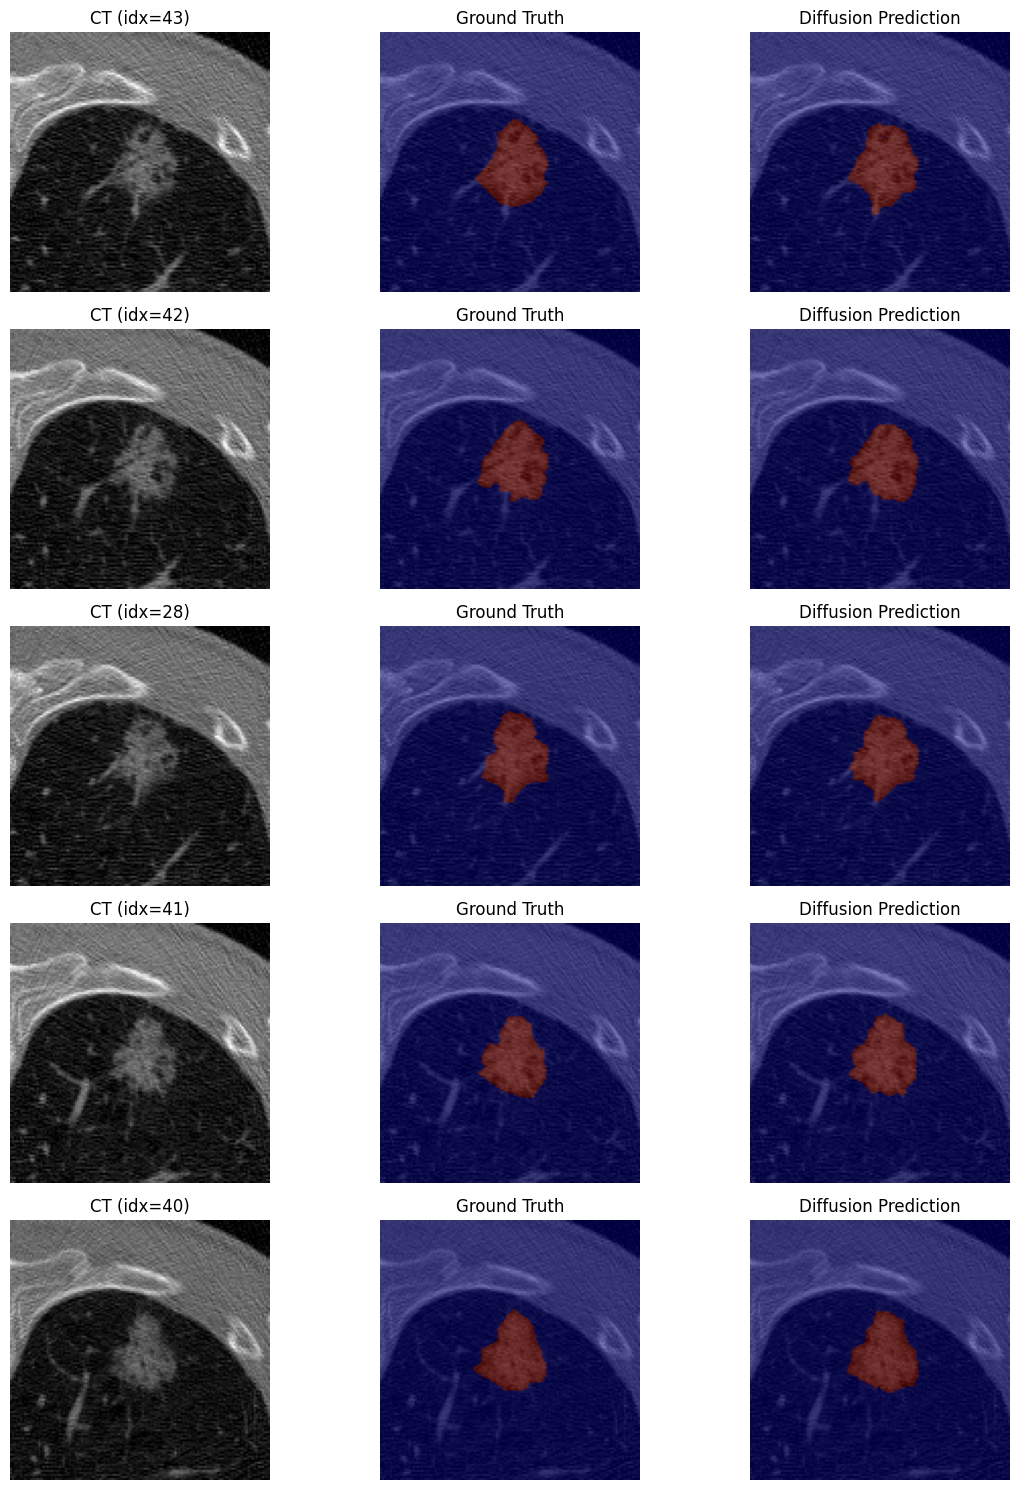

In [31]:
import torch
import numpy as np
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load diffusion model
diffusion_model = DiffusionUNet().to(device)

state_dict = torch.load(
    "best_diffusion_unet_lidc.pth",
    map_location=device,
    weights_only=True
)

diffusion_model.load_state_dict(state_dict)
diffusion_model.eval()

print("Diffusion model loaded successfully")
test_dataset = test_loader.dataset

# Get top 5 slices with largest tumors
slice_scores = []

for index in range(len(test_dataset)):
    _, mask_i = test_dataset[index]
    tumor_area = torch.sum(mask_i).item()
    slice_scores.append((tumor_area, index))

slice_scores.sort(reverse=True)
top5_indices = [idx for (_, idx) in slice_scores[:5]]

print("Top 5 indices:", top5_indices)

# Fixed inference timestep
inference_timestep = timesteps // 2

plt.figure(figsize=(12, 15))

for i, idx in enumerate(top5_indices):

    image, mask = test_dataset[idx]
    image_batch = image.unsqueeze(0).to(device)
    mask_batch = mask.unsqueeze(0).to(device)

    batch_size = image_batch.shape[0]

    t = torch.full(
        (batch_size,),
        inference_timestep,
        device=device,
        dtype=torch.long
    )

    with torch.no_grad():
        noisy_mask, _ = add_noise_to_mask(mask_batch, t)

        predicted_noise = diffusion_model(image_batch, noisy_mask, t)

        predicted_clean_mask_logits = reconstruct_clean_mask(
            noisy_mask,
            predicted_noise,
            t
        )

        predicted_clean_mask_logits = torch.clamp(
            predicted_clean_mask_logits,
            -6.0,
            6.0
        )

        probs = torch.sigmoid(predicted_clean_mask_logits)
        pred_mask = (probs > 0.5).float()

    image_np = image.squeeze().cpu().numpy()
    gt_mask_np = mask.squeeze().cpu().numpy()
    pred_mask_np = pred_mask.squeeze().cpu().numpy()

    # CT
    plt.subplot(5, 3, i * 3 + 1)
    plt.imshow(image_np, cmap="gray")
    plt.title(f"CT (idx={idx})")
    plt.axis("off")

    # Ground truth overlay
    plt.subplot(5, 3, i * 3 + 2)
    plt.imshow(image_np, cmap="gray")
    plt.imshow(gt_mask_np, alpha=0.5, cmap="jet")
    plt.title("Ground Truth")
    plt.axis("off")

    # Diffusion prediction overlay
    plt.subplot(5, 3, i * 3 + 3)
    plt.imshow(image_np, cmap="gray")
    plt.imshow(pred_mask_np, alpha=0.5, cmap="jet")
    plt.title("Diffusion Prediction")
    plt.axis("off")

plt.tight_layout()
plt.savefig("top5_diffusion_predictions_lidc.png", dpi=300, bbox_inches="tight")
plt.show()

Diffusion model loaded successfully
Top 5 indices: [43, 42, 28, 41, 40]


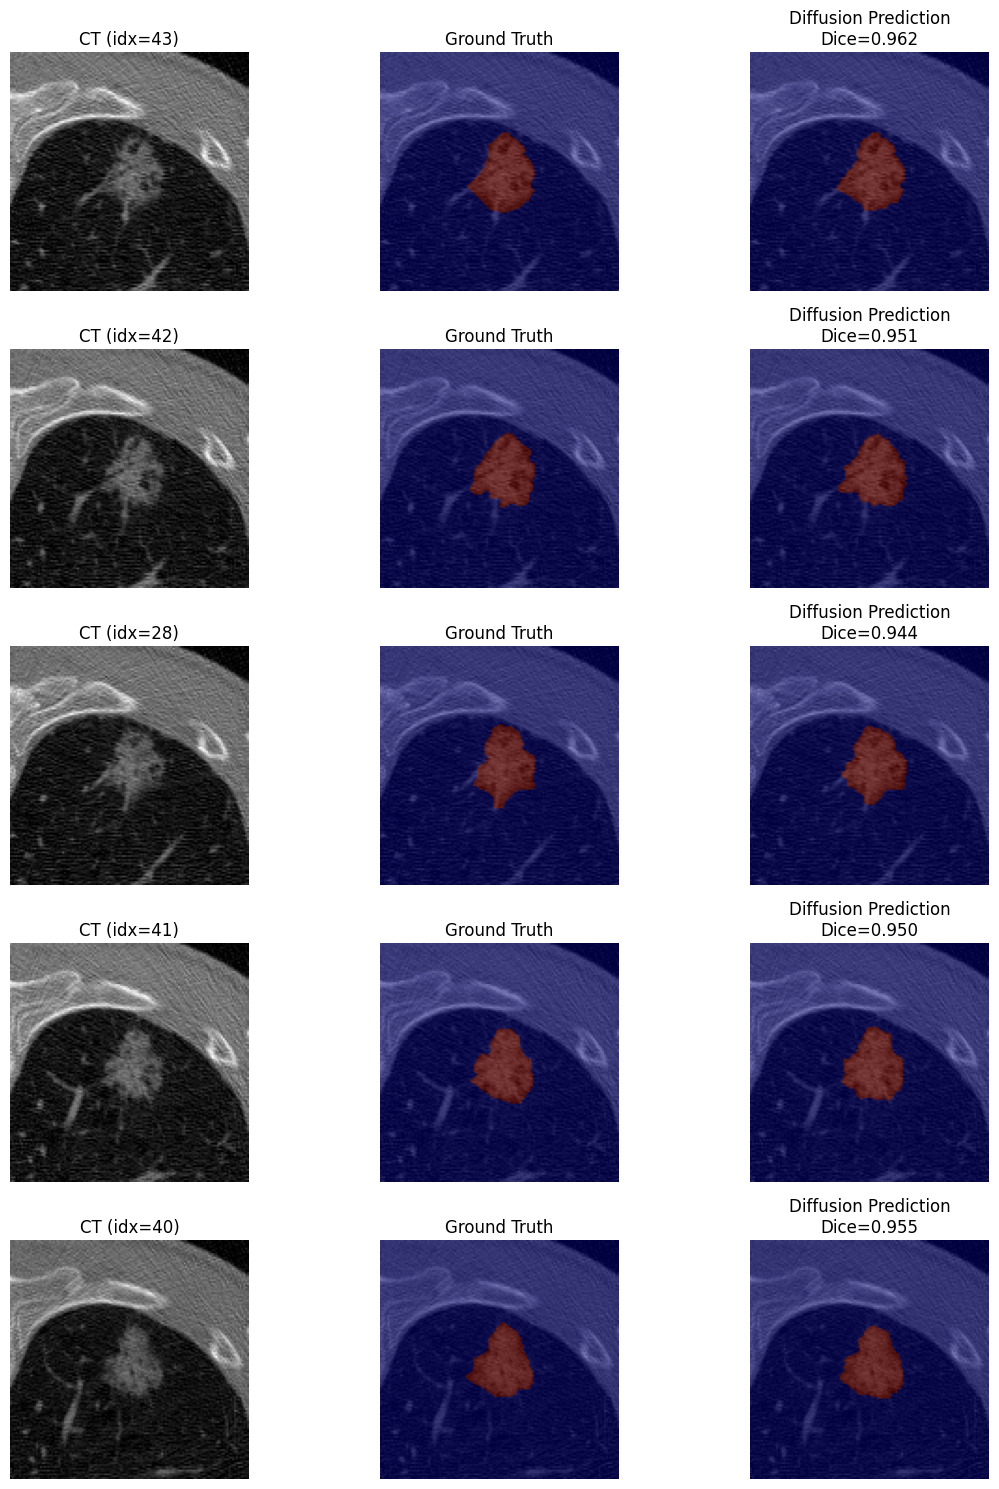

In [33]:
import torch
import numpy as np
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Dice Score Function
def dice_score(pred, target, smooth=1e-6):
    intersection = (pred * target).sum()
    union = pred.sum() + target.sum()
    return (2.0 * intersection + smooth) / (union + smooth)


# Load diffusion model
diffusion_model = DiffusionUNet().to(device)

state_dict = torch.load(
    "best_diffusion_unet_lidc.pth",
    map_location=device,
    weights_only=True
)

diffusion_model.load_state_dict(state_dict)
diffusion_model.eval()

print("Diffusion model loaded successfully")


# Get dataset from loader
test_dataset = test_loader.dataset


# Find top 5 largest tumors
slice_scores = []

for index in range(len(test_dataset)):
    _, mask_i = test_dataset[index]
    tumor_area = torch.sum(mask_i).item()
    slice_scores.append((tumor_area, index))

slice_scores.sort(reverse=True)
top5_indices = [idx for (_, idx) in slice_scores[:5]]

print("Top 5 indices:", top5_indices)


# Inference timestep

inference_timestep = timesteps // 2

plt.figure(figsize=(12, 15))


# Visualization loop
for i, idx in enumerate(top5_indices):

    image, mask = test_dataset[idx]

    image_batch = image.unsqueeze(0).to(device)
    mask_batch = mask.unsqueeze(0).to(device)

    batch_size = image_batch.shape[0]

    t = torch.full(
        (batch_size,),
        inference_timestep,
        device=device,
        dtype=torch.long
    )

    with torch.no_grad():
        noisy_mask, _ = add_noise_to_mask(mask_batch, t)

        predicted_noise = diffusion_model(image_batch, noisy_mask, t)

        predicted_clean_mask_logits = reconstruct_clean_mask(
            noisy_mask,
            predicted_noise,
            t
        )

        predicted_clean_mask_logits = torch.clamp(
            predicted_clean_mask_logits,
            -6.0,
            6.0
        )

        probs = torch.sigmoid(predicted_clean_mask_logits)
        pred_mask = (probs > 0.5).float()

    
        # Compute Dice Score
    
        dice = dice_score(pred_mask, mask_batch).item()

    # Convert to numpy
    image_np = image.squeeze().cpu().numpy()
    gt_mask_np = mask.squeeze().cpu().numpy()
    pred_mask_np = pred_mask.squeeze().cpu().numpy()

    
    # Plot CT
    
    plt.subplot(5, 3, i * 3 + 1)
    plt.imshow(image_np, cmap="gray")
    plt.title(f"CT (idx={idx})")
    plt.axis("off")

    
    # Ground Truth
    
    plt.subplot(5, 3, i * 3 + 2)
    plt.imshow(image_np, cmap="gray")
    plt.imshow(gt_mask_np, alpha=0.5, cmap="jet")
    plt.title("Ground Truth")
    plt.axis("off")

    
    # Prediction + Dice

    plt.subplot(5, 3, i * 3 + 3)
    plt.imshow(image_np, cmap="gray")
    plt.imshow(pred_mask_np, alpha=0.5, cmap="jet")
    plt.title(f"Diffusion Prediction\nDice={dice:.3f}")
    plt.axis("off")

plt.tight_layout()
plt.savefig("top5_diffusion_predictions_lidc.png", dpi=300, bbox_inches="tight")
plt.show()

Best patient: LIDC-IDRI-0436
Best nodule: nodule-0
Best image path: /scratch/ms4764/LIDC-IDRI-slices/LIDC-IDRI-slices/LIDC-IDRI-0436/nodule-0/images/slice-7.png
Best mask path: /scratch/ms4764/LIDC-IDRI-slices/LIDC-IDRI-slices/LIDC-IDRI-0436/nodule-0/mask-0/slice-7.png
Largest tumor area: 1766


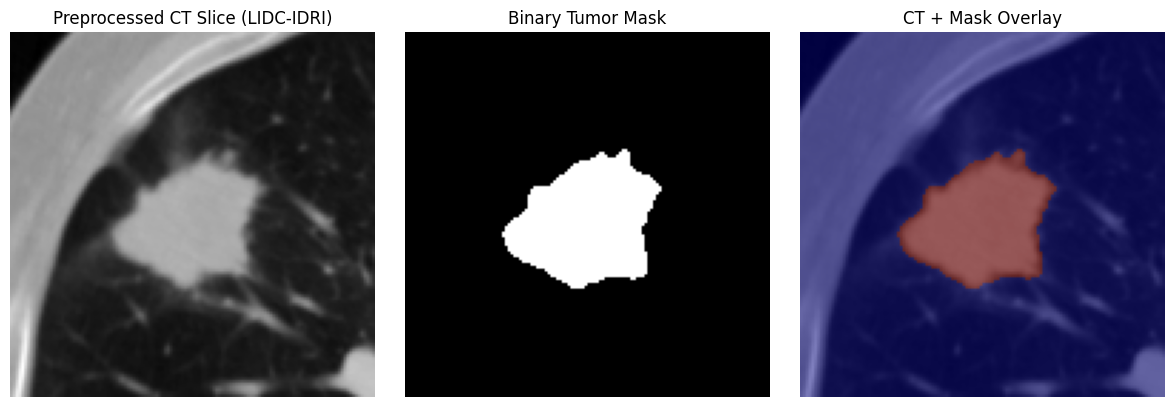

In [5]:
from pathlib import Path
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

dataset_path = Path("/scratch/ms4764/LIDC-IDRI-slices/LIDC-IDRI-slices")

best_tumor_area = 0
best_image_path = None
best_mask_path = None
best_patient = None
best_nodule = None

for patient in sorted(dataset_path.iterdir()):
    if not patient.is_dir() or patient.name.startswith("."):
        continue

    for nodule in sorted(patient.iterdir()):
        if not nodule.is_dir() or nodule.name.startswith("."):
            continue

        image_folder = nodule / "images"
        mask_folder = nodule / "mask-0"

        if not image_folder.exists() or not mask_folder.exists():
            continue

        image_files = sorted(image_folder.glob("*.png"))
        mask_files = sorted(mask_folder.glob("*.png"))

        number_of_files = min(len(image_files), len(mask_files))

        for file_index in range(number_of_files):
            image_path = image_files[file_index]
            mask_path = mask_files[file_index]

            mask = np.array(Image.open(mask_path))
            binary_mask = mask > 0
            tumor_area = np.sum(binary_mask)

            if tumor_area > best_tumor_area:
                best_tumor_area = tumor_area
                best_image_path = image_path
                best_mask_path = mask_path
                best_patient = patient.name
                best_nodule = nodule.name

print("Best patient:", best_patient)
print("Best nodule:", best_nodule)
print("Best image path:", best_image_path)
print("Best mask path:", best_mask_path)
print("Largest tumor area:", best_tumor_area)

image = np.array(Image.open(best_image_path)).astype(np.float32)
mask = np.array(Image.open(best_mask_path))

image = image / 255.0
mask = (mask > 0).astype(np.uint8)

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(image, cmap="gray")
plt.title("Preprocessed CT Slice (LIDC-IDRI)")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(mask, cmap="gray")
plt.title("Binary Tumor Mask")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(image, cmap="gray")
plt.imshow(mask, alpha=0.5, cmap="jet")
plt.title("CT + Mask Overlay")
plt.axis("off")

plt.tight_layout()
plt.savefig("lidc_preprocessed_example.png", dpi=300, bbox_inches="tight")
plt.show()